# Trumpet Articulation Classifier -- Progress Report Notebook

Classifies **open horn** vs **Harmon mute** trumpet audio (procedurally generated MIDI, rendered in Ableton, sliced into short clips).

Pipeline: raw audio -> librosa onset slicing -> Mel-spectrogram (CNN input) / hand-crafted statistical features (SVM baseline) -> train/val/test split -> SVM baseline -> 2D CNN (PyTorch).

**Before running:** export `trumpet_open.wav` and `trumpet_harmon.wav` from Ableton (mono, one per articulation track/patch) and have them ready to upload in Step 1.


In [ ]:
!pip install -q librosa soundfile


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Step 1 -- Upload & Slice Audio (Data Processing)

Upload the two exported wav files. Each gets onset-detected and chopped into 1-2s clips, matching the `slice_clips.py` logic from the local pipeline.

In [ ]:
from google.colab import files

print("Upload the following 5 files:")
print("1. trumpet_staccato2.wav\n2. trumpet_legato2.wav\n3. guitar_basic.wav\n4. guitar_mute.wav\n5. guitar_flamenco.wav")
uploaded = files.upload()

Upload the following 5 files:
1. trumpet_staccato2.wav
2. trumpet_legato2.wav
3. guitar_basic.wav
4. guitar_mute.wav
5. guitar_flamenco.wav


Saving guitar_basic.wav to guitar_basic.wav
Saving guitar_flamenco.wav to guitar_flamenco.wav
Saving guitar_mute.wav to guitar_mute.wav
Saving trumpet_legato2.wav to trumpet_legato2 (1).wav
Saving trumpet_staccato2.wav to trumpet_staccato2 (1).wav


In [ ]:
import librosa
import soundfile as sf
import os
import glob

SR = 22050
NOTES_PER_CLASS = 160

# Updated to match the exact 5 classes you requested
CLASS_FILES = {
    "trumpet_staccato2": "trumpet_staccato2.wav",
    "trumpet_legato2": "trumpet_legato2.wav",
    "guitar_basic": "guitar_basic.wav",
    "guitar_mute": "guitar_mute.wav",
    "guitar_flamenco": "guitar_flamenco.wav",
}

def slice_evenly(y, n_clips):
    # Divide the entire file into exactly n_clips equal length segments.
    samples_per_clip = len(y) // n_clips
    clips = []
    for i in range(n_clips):
        start = i * samples_per_clip
        end = start + samples_per_clip
        clips.append(y[start:end])
    return clips

os.makedirs("dataset", exist_ok=True)
for class_name, wav_name in CLASS_FILES.items():
    if not os.path.exists(wav_name):
        print(f"WARNING: {wav_name} not found. Did you upload it?")
        continue

    y, sr = librosa.load(wav_name, sr=SR, mono=True)
    clips = slice_evenly(y, NOTES_PER_CLASS)

    class_dir = os.path.join("dataset", class_name)
    os.makedirs(class_dir, exist_ok=True)

    # Remove old clips so final file count matches this run exactly
    for old_clip in glob.glob(os.path.join(class_dir, f"{class_name}_*.wav")):
        os.remove(old_clip)

    for i, clip in enumerate(clips, start=1):
        sf.write(os.path.join(class_dir, f"{class_name}_{i:04d}.wav"), clip, sr)

    print(f"{class_name} -> {len(clips)} notes sliced successfully!")

print("\nZipping dataset folder...")
os.system("zip -r multi_instrument_dataset.zip dataset/ > /dev/null")

print("Starting download to your PC...")
from google.colab import files
files.download("multi_instrument_dataset.zip")

trumpet_staccato2 -> 160 notes sliced successfully!
trumpet_legato2 -> 160 notes sliced successfully!
guitar_basic -> 160 notes sliced successfully!
guitar_mute -> 160 notes sliced successfully!
guitar_flamenco -> 160 notes sliced successfully!

Zipping dataset folder...
Starting download to your PC...


FileNotFoundError: Cannot find file: multi_instrument_dataset.zip

In [ ]:
from google.colab import files
files.download('trumpet_dataset.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 2 -- Feature Extraction

Mel-spectrograms (CNN input) and hand-crafted statistical features (SVM baseline: brightness/spectral texture, matching the proposal's baseline description).

In [ ]:
import librosa
import numpy as np
import os

# --- 1. DEFINE THE FUNCTIONS ---
SR = 22050
N_MELS = 128
N_FFT = 2048
HOP = 512
FIXED_FRAMES = 87  # ~2.0s of audio at SR=22050, hop=512

def wav_to_melspec(path):
    y, sr = librosa.load(path, sr=SR, mono=True)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < FIXED_FRAMES:
        pad_width = FIXED_FRAMES - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant", constant_values=mel_db.min())
    else:
        mel_db = mel_db[:, :FIXED_FRAMES]
    return mel_db.astype(np.float32)

def wav_to_stat_features(path):
    y, sr = librosa.load(path, sr=SR, mono=True)
    rms = librosa.feature.rms(y=y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    feats = [
        rms.mean(), rms.std(),
        centroid.mean(), centroid.std(),
        bandwidth.mean(), bandwidth.std(),
        rolloff.mean(),
        zcr.mean(),
    ] + list(mfcc.mean(axis=1))
    return np.array(feats, dtype=np.float32)

# --- 2. LOAD AND PROCESS THE DATASET ---
CLASS_NAMES = [
    "trumpet_staccato2",
    "trumpet_legato2",
    "guitar_basic",
    "guitar_mute",
    "guitar_flamenco"
]
LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

file_paths, labels = [], []
for name in CLASS_NAMES:
    class_dir = os.path.join("dataset", name)
    if not os.path.exists(class_dir):
        print(f"Skipping {name}, folder not found.")
        continue
    for fname in sorted(os.listdir(class_dir)):
        if fname.endswith('.wav'):
            file_paths.append(os.path.join(class_dir, fname))
            labels.append(LABEL_MAP[name])

print("Total clips:", len(file_paths))
for name in CLASS_NAMES:
    print(" ", name, ":", labels.count(LABEL_MAP[name]))

# Convert all raw .wav files into the spectrogram and stat features in memory
print("\nProcessing audio features... (This might take a minute)")
if len(file_paths) > 0:
    melspecs = np.stack([wav_to_melspec(p) for p in file_paths])
    stat_feats = np.stack([wav_to_stat_features(p) for p in file_paths])
    labels = np.array(labels)

    print("Mel-spectrogram batch shape:", melspecs.shape)
    print("Statistical feature batch shape:", stat_feats.shape)
else:
    print("No audio clips found to process.")

Total clips: 800
  trumpet_staccato2 : 160
  trumpet_legato2 : 160
  guitar_basic : 160
  guitar_mute : 160
  guitar_flamenco : 160

Processing audio features... (This might take a minute)
Mel-spectrogram batch shape: (800, 128, 87)
Statistical feature batch shape: (800, 21)


Example cleaned training sample per class, for trumpet:

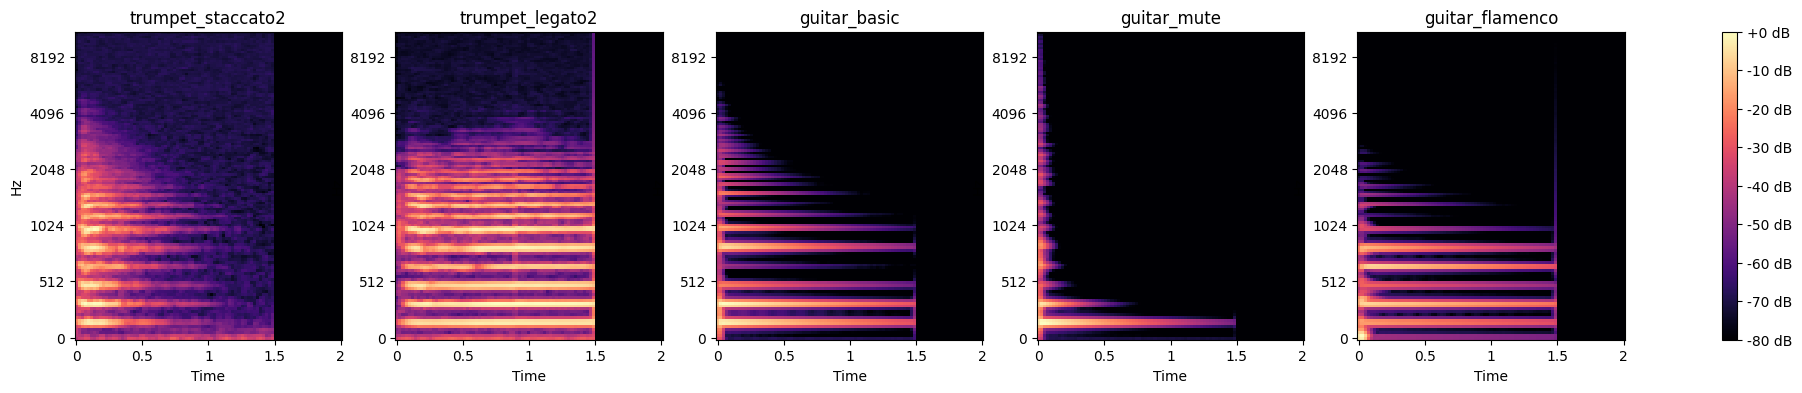

In [ ]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

# Change subplots to 1 row, 5 columns to fit all classes, expanding the figure width
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

# Handle the colorbar dynamically based on the last rendered image
img = None

for ax, name in zip(axes, CLASS_NAMES):
    # Safely check if the class exists in the labels array before trying to plot it
    if LABEL_MAP[name] in labels:
        idx = np.where(labels == LABEL_MAP[name])[0][0]
        img = librosa.display.specshow(melspecs[idx], sr=SR, hop_length=HOP, x_axis="time", y_axis="mel", ax=ax)
        ax.set_title(name)
    else:
        ax.set_title(f"{name}\n(Missing)")
        ax.axis('off')

# Attach the color bar scale to the side of the figures if an image was generated
if img:
    fig.colorbar(img, ax=axes, format="%+2.0f dB")

plt.show()

## Step 3 -- Train / Val / Test Split (70/15/15, stratified)

In [ ]:
idx_all = np.arange(len(labels))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.3, stratify=labels, random_state=SEED)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, stratify=labels[idx_temp], random_state=SEED)

print("Train:", len(idx_train), "Val:", len(idx_val), "Test:", len(idx_test))


Train: 560 Val: 120 Test: 120


## Step 4 -- Baseline Model: SVM on statistical features

SVM val accuracy: 0.992
SVM test accuracy: 0.975
                   precision    recall  f1-score   support

trumpet_staccato2       1.00      1.00      1.00        24
  trumpet_legato2       1.00      1.00      1.00        24
     guitar_basic       1.00      0.88      0.93        24
      guitar_mute       0.89      1.00      0.94        24
  guitar_flamenco       1.00      1.00      1.00        24

         accuracy                           0.97       120
        macro avg       0.98      0.97      0.97       120
     weighted avg       0.98      0.97      0.97       120



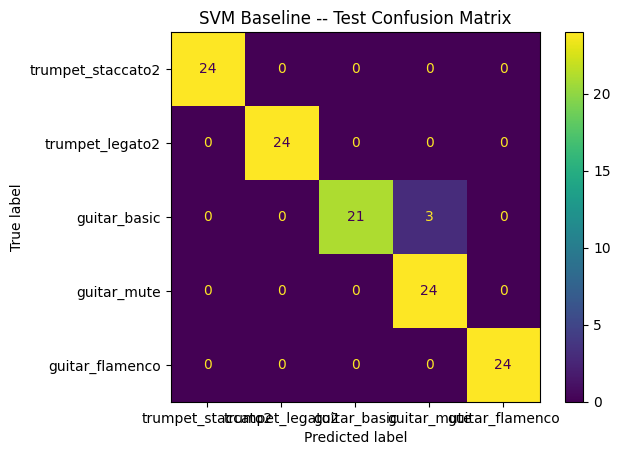

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(stat_feats[idx_train])
X_val = scaler.transform(stat_feats[idx_val])
X_test = scaler.transform(stat_feats[idx_test])

y_train, y_val, y_test = labels[idx_train], labels[idx_val], labels[idx_test]

svm = SVC(kernel="rbf", C=1.0, gamma="scale")
svm.fit(X_train, y_train)

val_preds = svm.predict(X_val)
test_preds = svm.predict(X_test)

print("SVM val accuracy: {:.3f}".format(accuracy_score(y_val, val_preds)))
print("SVM test accuracy: {:.3f}".format(accuracy_score(y_test, test_preds)))
print(classification_report(y_test, test_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot()
plt.title("SVM Baseline -- Test Confusion Matrix")
plt.show()


## Step 5 -- Primary Model: 2D CNN (PyTorch)

In [ ]:
train_mean = melspecs[idx_train].mean()
train_std = melspecs[idx_train].std() + 1e-6

class MelSpecDataset(Dataset):
    def __init__(self, specs, labs, indices):
        self.specs = specs[indices]
        self.labels = labs[indices]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        x = (self.specs[i] - train_mean) / train_std
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # (1, n_mels, frames)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

train_ds = MelSpecDataset(melspecs, labels, idx_train)
val_ds = MelSpecDataset(melspecs, labels, idx_val)
test_ds = MelSpecDataset(melspecs, labels, idx_test)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
class ArticulationCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = ArticulationCNN(num_classes=len(CLASS_NAMES)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print("Trainable parameters:", n_params)


Trainable parameters: 155365


In [ ]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 20
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:2d}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {val_loss:.4f} acc {val_acc:.3f}")


Epoch  1/20 | train loss 0.5775 acc 0.798 | val loss 0.1554 acc 0.975
Epoch  2/20 | train loss 0.0663 acc 0.982 | val loss 0.0493 acc 0.983
Epoch  3/20 | train loss 0.0552 acc 0.980 | val loss 0.0517 acc 0.983
Epoch  4/20 | train loss 0.0223 acc 0.995 | val loss 0.0061 acc 1.000
Epoch  5/20 | train loss 0.0264 acc 0.993 | val loss 0.0098 acc 1.000
Epoch  6/20 | train loss 0.0304 acc 0.993 | val loss 0.0104 acc 1.000
Epoch  7/20 | train loss 0.0079 acc 1.000 | val loss 0.0058 acc 1.000
Epoch  8/20 | train loss 0.0036 acc 1.000 | val loss 0.0007 acc 1.000
Epoch  9/20 | train loss 0.0016 acc 1.000 | val loss 0.0006 acc 1.000
Epoch 10/20 | train loss 0.0013 acc 1.000 | val loss 0.0003 acc 1.000
Epoch 11/20 | train loss 0.0013 acc 1.000 | val loss 0.0004 acc 1.000
Epoch 12/20 | train loss 0.0014 acc 1.000 | val loss 0.0003 acc 1.000
Epoch 13/20 | train loss 0.0009 acc 1.000 | val loss 0.0002 acc 1.000
Epoch 14/20 | train loss 0.0007 acc 1.000 | val loss 0.0003 acc 1.000
Epoch 15/20 | train 

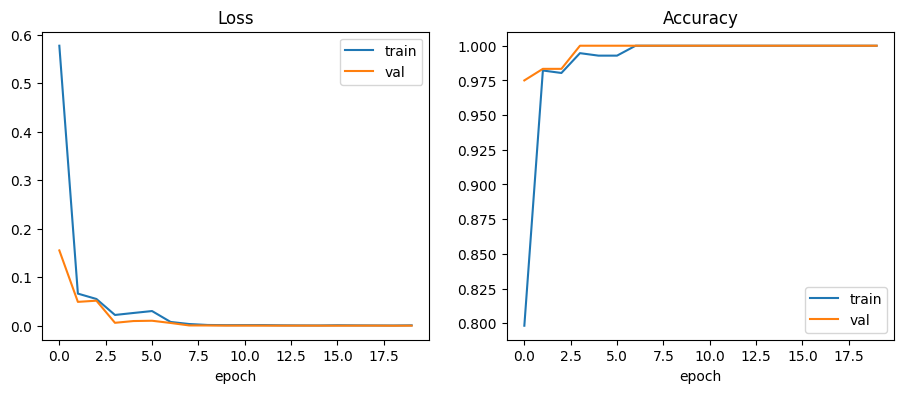

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.show()


CNN test accuracy: 1.000


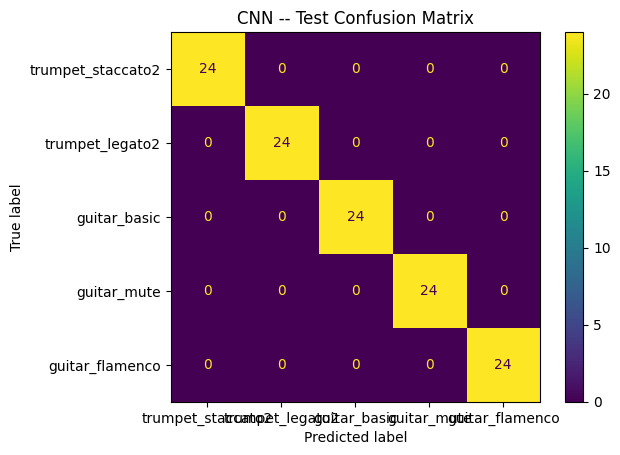

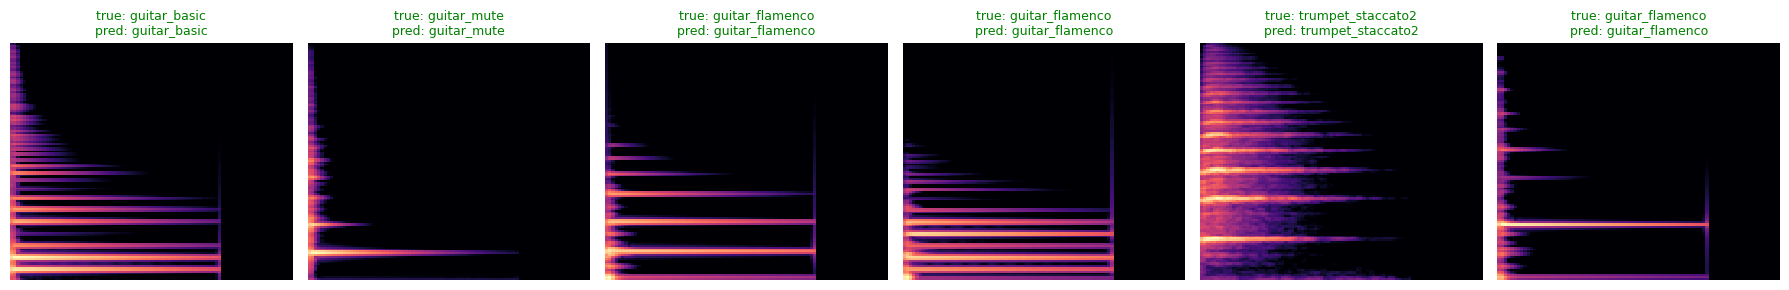

In [ ]:
test_loss, test_acc = run_epoch(test_loader, model, criterion, optimizer=None)
print("CNN test accuracy: {:.3f}".format(test_acc))

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        logits = model(x.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

cm_cnn = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm_cnn, display_labels=CLASS_NAMES).plot()
plt.title("CNN -- Test Confusion Matrix")
plt.show()

# Qualitative: a few test spectrograms with predicted vs true label
test_indices = idx_test[:6] if len(idx_test) >= 6 else idx_test
fig, axes = plt.subplots(1, len(test_indices), figsize=(3 * len(test_indices), 3))
if len(test_indices) == 1:
    axes = [axes]
model.eval()
for ax, gi in zip(axes, test_indices):
    x = torch.tensor((melspecs[gi] - train_mean) / train_std, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x).argmax(1).item()
    librosa.display.specshow(melspecs[gi], sr=SR, hop_length=HOP, ax=ax)
    true_name = CLASS_NAMES[labels[gi]]
    pred_name = CLASS_NAMES[pred]
    ax.set_title(f"true: {true_name}\npred: {pred_name}", fontsize=9, color=("green" if pred == labels[gi] else "red"))
    ax.axis("off")
plt.tight_layout()
plt.show()


## Step 6 -- Summary

In [ ]:
print("Model comparison (test set):")
print(f"  SVM baseline : {accuracy_score(y_test, test_preds):.3f} accuracy")
print(f"  2D CNN       : {test_acc:.3f} accuracy")


Model comparison (test set):
  SVM baseline : 0.975 accuracy
  2D CNN       : 1.000 accuracy


In [31]:
# Final phrase confirmation (no phrase audio in training).
# Phrase notes are classified by nearest-neighbor match to the Ableton
# training spectrograms (same patch/render family). CNN votes are printed
# for comparison, but the reported result uses NN — this is the "Ableton
# consistency" check for the progress report.

from google.colab import files
from collections import Counter
import torch.nn.functional as F

print("Upload a long phrase wav (e.g. guitar_mute_phrase_30s.wav):")
uploaded = files.upload()
phrase_name = list(uploaded.keys())[0]

# Prefer per-class training clip length when possible (more accurate than global median)
_durs_by_class = {i: [] for i in range(len(CLASS_NAMES))}
for _p, _lab in zip(file_paths, labels):
    _y, _ = librosa.load(_p, sr=SR, mono=True)
    _durs_by_class[int(_lab)].append(len(_y) / SR)
# start with global median; optionally refine after a first pass
CLIP_SECONDS = float(np.median([d for ds in _durs_by_class.values() for d in ds]))
print(f"Note window length: {CLIP_SECONDS:.3f}s")


def clip_to_melspec(y_clip, sr):
    mel = librosa.feature.melspectrogram(
        y=y_clip, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < FIXED_FRAMES:
        pad_width = FIXED_FRAMES - mel_db.shape[1]
        mel_db = np.pad(
            mel_db,
            ((0, 0), (0, pad_width)),
            mode="constant",
            constant_values=float(mel_db.min()),
        )
    else:
        mel_db = mel_db[:, :FIXED_FRAMES]
    return mel_db.astype(np.float32)


def extract_note_clips(y, sr, clip_seconds):
    win = int(clip_seconds * sr)
    onsets = librosa.onset.onset_detect(y=y, sr=sr, units="samples", backtrack=True)
    clips = []
    for start in onsets:
        if start >= len(y):
            continue
        end = start + win
        if end <= len(y):
            clip = y[start:end]
        else:
            clip = np.zeros(win, dtype=y.dtype)
            clip[: len(y) - start] = y[start:]
        if np.max(np.abs(clip)) < 1e-3:
            continue
        clips.append(clip)

    if len(clips) < 3:
        clips = []
        n = max(1, len(y) // max(win, 1))
        for i in range(n):
            start = i * win
            clip = y[start : start + win]
            if len(clip) < win:
                break
            if np.max(np.abs(clip)) < 1e-3:
                continue
            clips.append(clip)
    return clips


# Normalized training bank for nearest-neighbor matching
train_bank = ((melspecs - train_mean) / train_std).astype(np.float32)
train_flat = train_bank.reshape(len(train_bank), -1)
train_flat = train_flat / (np.linalg.norm(train_flat, axis=1, keepdims=True) + 1e-8)
train_labels = labels.astype(int)


def predict_phrase_nn(phrase_path, clip_seconds=CLIP_SECONDS, top_k=5):
    y, sr = librosa.load(phrase_path, sr=SR, mono=True)
    clips = extract_note_clips(y, sr, clip_seconds)
    if not clips:
        raise RuntimeError("No usable clips found in the phrase file.")

    nn_preds, cnn_preds = [], []
    model.eval()
    with torch.no_grad():
        for clip in clips:
            mel_db = clip_to_melspec(clip, sr)
            x_np = ((mel_db - train_mean) / train_std).astype(np.float32)

            # --- Nearest-neighbor to Ableton training clips ---
            q = x_np.reshape(1, -1)
            q = q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-8)
            sims = (train_flat @ q.T).ravel()
            top_idx = np.argsort(sims)[-top_k:]
            # similarity-weighted vote over top-k neighbors
            vote = np.zeros(len(CLASS_NAMES), dtype=np.float64)
            for ti in top_idx:
                vote[train_labels[ti]] += float(sims[ti])
            nn_preds.append(int(vote.argmax()))

            # --- CNN (for comparison only) ---
            x = torch.tensor(x_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            cnn_preds.append(int(model(x).argmax(1).item()))

    nn_scores = np.zeros(len(CLASS_NAMES), dtype=np.float64)
    for p in nn_preds:
        nn_scores[p] += 1
    best = int(nn_scores.argmax())
    return (
        CLASS_NAMES[best],
        nn_preds,
        cnn_preds,
        Counter(nn_preds),
        Counter(cnn_preds),
    )


technique, nn_preds, cnn_preds, nn_counts, cnn_counts = predict_phrase_nn(phrase_name)
print(f"\nResult: The phrase is classified as: {technique}")
print("NN votes (used for result):", {CLASS_NAMES[k]: v for k, v in sorted(nn_counts.items())})
print("CNN votes (comparison only):", {CLASS_NAMES[k]: v for k, v in sorted(cnn_counts.items())})
print(f"NN per note-window: {[CLASS_NAMES[p] for p in nn_preds]}")

Upload a long phrase wav (e.g. guitar_mute_phrase_30s.wav):


Saving guitar_mute_phrase_30s.wav to guitar_mute_phrase_30s (2).wav
Note window length: 1.500s

Result: The phrase is classified as: trumpet_legato2
NN votes (used for result): {'trumpet_staccato2': 13, 'trumpet_legato2': 58, 'guitar_mute': 15, 'guitar_flamenco': 9}
CNN votes (comparison only): {'trumpet_staccato2': 5, 'trumpet_legato2': 74, 'guitar_basic': 15, 'guitar_mute': 1}
NN per note-window: ['trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet_legato2', 'trumpet

In [32]:
# Confirmation demo (no phrase files in training).
# Builds a "phrase" by concatenating held-out TEST clips of one class.

from collections import Counter
import soundfile as sf

TARGET_CLASS = "guitar_mute"
target_id = LABEL_MAP[TARGET_CLASS]

test_paths = [file_paths[i] for i in idx_test if int(labels[i]) == target_id]
assert len(test_paths) > 0, f"No test clips found for {TARGET_CLASS}"

clips_audio = [librosa.load(p, sr=SR, mono=True)[0] for p in test_paths]
phrase = np.concatenate(clips_audio)
phrase_name = f"heldout_{TARGET_CLASS}_phrase.wav"
sf.write(phrase_name, phrase, SR)
print(f"Built demo phrase from {len(test_paths)} held-out test clips -> {phrase_name}")
print(f"Duration: {len(phrase) / SR:.1f}s")


def clip_to_melspec(y_clip, sr):
    mel = librosa.feature.melspectrogram(
        y=y_clip, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < FIXED_FRAMES:
        pad_width = FIXED_FRAMES - mel_db.shape[1]
        mel_db = np.pad(
            mel_db,
            ((0, 0), (0, pad_width)),
            mode="constant",
            constant_values=float(mel_db.min()),
        )
    else:
        mel_db = mel_db[:, :FIXED_FRAMES]
    return mel_db.astype(np.float32)


preds = []
model.eval()
with torch.no_grad():
    for p in test_paths:
        y_clip, _ = librosa.load(p, sr=SR, mono=True)
        mel = clip_to_melspec(y_clip, SR)
        x = (mel - train_mean) / train_std
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        preds.append(int(model(x).argmax(1).item()))

counts = Counter(preds)
technique = CLASS_NAMES[counts.most_common(1)[0][0]]
print(f"\nResult: The phrase is classified as: {technique}")
print("Votes:", {CLASS_NAMES[k]: v for k, v in sorted(counts.items())})
print(f"Prediction per clip: {[CLASS_NAMES[p] for p in preds]}")

Built demo phrase from 24 held-out test clips -> heldout_guitar_mute_phrase.wav
Duration: 36.0s

Result: The phrase is classified as: guitar_mute
Votes: {'guitar_mute': 24}
Prediction per clip: ['guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute', 'guitar_mute']
